# ICU Sepsis Mortality Analysis

## Project Overview

This project analyzes ICU patient data to identify factors associated with mortality among patients with sepsis. The analysis includes data cleaning, feature engineering, exploratory data analysis (EDA), and identification of clinical factors associated with patient outcomes.

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook

**Author:** Vanessa Lowry, RN, PhD


## Data Source and Citation

This project utilizes a publicly available ICU sepsis dataset obtained from Kaggle and was developed for educational and portfolio purposes.

**Dataset Citation**

Shereef, S. (n.d.). *MIMIC-IV Style ICU Dataset for Sepsis Prediction*. Kaggle. Retrieved from https://www.kaggle.com/datasets/sinanshereef/mimic-iv-style-icu-dataset-for-sepsis-prediction

**Acknowledgment**

Portions of the analytical approach and exploratory workflow were informed by the publicly available Kaggle notebook:

Chowdhury, N. (n.d.). *Mortality Detection of ICU Admitted Sepsis Patients*. Kaggle. Retrieved from https://www.kaggle.com/code/nabanichowdhury/mortality-detection-of-icu-admitted-sepsis

## Privacy and Ethical Considerations

The dataset used in this project was obtained from a publicly available source and contains de-identified information. No protected health information (PHI) was accessed, used, or disclosed during this analysis. All findings are presented for educational and portfolio purposes only and should not be interpreted as clinical recommendations.


## Business Objective

The goal of this analysis is to explore demographic, clinical, and admission-related factors associated with mortality in ICU patients with sepsis.

### Key Questions
1. What is the overall mortality rate?
2. Which patient characteristics are associated with mortality?
3. Does comorbidity burden impact outcomes?
4. Are outcomes different by admission type?
5. What variables may be useful for future predictive modeling?


## Data Loading and Initial Setup

In [72]:
# Import core Python libraries for data analysis.
# NumPy supports numerical operations, while pandas is used for loading, cleaning,
# and analyzing tabular healthcare data.
import numpy as np
import pandas as pd

# Load the ICU dataset from a CSV file.
df = pd.read_csv('icu_info.csv')

# Preview the first few rows to understand the structure of the dataset.
df.head()

,Patient_Accommodation,Age,Gender,Comorbidity,Solid_organ_cancer,Hematological_Diseases,Hypertension,Heart_Diseases,Diabetes_mellitus,Chronic_Renal_Failure,...,Creatinine,NT_PRO_BNP_Pro_Brain_Natriuretic_Peptide,Systemic_Inflammatory_Response_Syndrome_SIRS_presence,The_National_Early_Warning_Score_NEWS,qSOFA_Score,History_of_hospitalization_in_the_last_3_months,Reproduction_in_Blood_Culture,Direnç_Durumu,Culture_Type,Antibioterapy
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,67.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,2.94,2525.00,0.0,1.0,0.0,1.0,1.0,metisilin dirençli,AEROB KAN KÜLTÜRÜ,Clindamycin
2,1.0,35.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.68,301.10,0.0,10.0,2.0,1.0,1.0,0,AEROB KAN KÜLTÜRÜ,Gentamicin High Level(synergy)
3,1.0,86.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.54,0.54,0.0,7.0,2.0,1.0,1.0,metisilin dirençli,AEROB KAN KÜLTÜRÜ,Daptomycin
4,1.0,43.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.71,0.71,0.0,8.0,2.0,1.0,0.0,0,0,0


In [73]:
# Display column names, data types, and non-null counts for an initial data quality check.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 43 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Patient_Accommodation                                  2938 non-null   float64
 1   Age                                                    2938 non-null   float64
 2   Gender                                                 2938 non-null   float64
 3   Comorbidity                                            2938 non-null   float64
 4   Solid_organ_cancer                                     1570 non-null   float64
 5   Hematological_Diseases                                 1570 non-null   float64
 6   Hypertension                                           1570 non-null   float64
 7   Heart_Diseases                                         1570 non-null   float64
 8   Diabetes_mellitus                               

In [74]:
# Standardize column names so they are easier to work with in Python.
# This converts names to lowercase, removes leading/trailing spaces,
# and replaces spaces with underscores.
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

In [75]:
# Re-check the dataset after standardizing column names.
# This confirms that the column cleanup was applied correctly.
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 43 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   patient_accommodation                                  2938 non-null   float64
 1   age                                                    2938 non-null   float64
 2   gender                                                 2938 non-null   float64
 3   comorbidity                                            2938 non-null   float64
 4   solid_organ_cancer                                     1570 non-null   float64
 5   hematological_diseases                                 1570 non-null   float64
 6   hypertension                                           1570 non-null   float64
 7   heart_diseases                                         1570 non-null   float64
 8   diabetes_mellitus                               

In [76]:
# Create a translation/renaming dictionary for selected variables.
# Several original column names appear to be in Turkish or contain special characters,
# so they are renamed into clearer English labels for readability and recruiter review.
translation_map = {
    "ek_hastalık_isimlerş": "comorbidity_names",
    "koah_asthım": "copd_asthma",
    "glukoz": "glucose",
    "mortalite": "mortality",
    "direnç_durumu": "antibiotic_resistance",
    "antibioterapy": "antibiotic_therapy"
}

In [77]:
# Rename selected columns using the translation map above.
# This makes the analysis easier to understand for non-technical and clinical reviewers.
df = df.rename(columns=translation_map)

In [78]:
# Review the updated column names and dataset structure after renaming.
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 43 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   patient_accommodation                                  2938 non-null   float64
 1   age                                                    2938 non-null   float64
 2   gender                                                 2938 non-null   float64
 3   comorbidity                                            2938 non-null   float64
 4   solid_organ_cancer                                     1570 non-null   float64
 5   hematological_diseases                                 1570 non-null   float64
 6   hypertension                                           1570 non-null   float64
 7   heart_diseases                                         1570 non-null   float64
 8   diabetes_mellitus                               

In [79]:
# Check for duplicate patient records.
# Duplicate rows can bias summary statistics and outcome rates if not removed.
df.duplicated().sum()

1516

In [80]:
# Remove exact duplicate rows from the dataset.
# This helps ensure each record is only counted once in the analysis.
df = df.drop_duplicates()

In [81]:
# Confirm that duplicate rows were removed successfully.
df.duplicated().sum()

0

## Data Quality Assessment

This section evaluates duplicate records and missing data to determine appropriate cleaning and imputation strategies.


In [82]:
# Count missing values in each column and sort from highest to lowest.
# This provides an initial view of where data quality issues may exist.
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

copd_asthma                                              1435
hypertension                                             1435
others                                                   1435
neurological_diseases                                    1435
diabetes_mellitus                                        1435
heart_diseases                                           1435
chronic_renal_failure                                    1435
hematological_diseases                                   1435
solid_organ_cancer                                       1435
nt_pro_bnp_pro_brain_natriuretic_peptide                  751
monocyte_count                                            196
lymphocyte_count                                          176
neutrophil_count                                          175
eosinophil_count                                          162
hct                                                       156
rbc                                                       156
wbc     

In [83]:
# Calculate both the number and percentage of missing values for each variable.
# Percent missing is useful for deciding how to handle each variable during cleaning.
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

# Combine missing counts and percentages into a single summary table.
missing_table = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_percent
}).sort_values(by='missing_percent', ascending=False)

missing_table

,missing_count,missing_percent
copd_asthma,1435,47.753744
hypertension,1435,47.753744
others,1435,47.753744
neurological_diseases,1435,47.753744
diabetes_mellitus,1435,47.753744
heart_diseases,1435,47.753744
chronic_renal_failure,1435,47.753744
hematological_diseases,1435,47.753744
solid_organ_cancer,1435,47.753744
nt_pro_bnp_pro_brain_natriuretic_peptide,751,24.991681


In [84]:
# Identify variables with more than 40% missing data.
# These variables may require careful interpretation or exclusion from future modeling.
high_missing = missing_table[missing_table['missing_percent'] > 40]
high_missing

,missing_count,missing_percent
copd_asthma,1435,47.753744
hypertension,1435,47.753744
others,1435,47.753744
neurological_diseases,1435,47.753744
diabetes_mellitus,1435,47.753744
heart_diseases,1435,47.753744
chronic_renal_failure,1435,47.753744
hematological_diseases,1435,47.753744
solid_organ_cancer,1435,47.753744


## Feature Engineering

New variables are created to improve analysis, including a comorbidity score and indicators for missing clinical information.


In [85]:
# Define the comorbidity columns used to summarize chronic disease burden.
# These variables represent clinical conditions that may influence ICU outcomes.
comorbidity_cols = [
    "copd_asthma",
    "hypertension",
    "others",
    "neurological_diseases",
    "diabetes_mellitus",
    "heart_diseases",
    "chronic_renal_failure",
    "hematological_diseases",
    "solid_organ_cancer"
]

# Create a flag indicating whether any comorbidity data is available for each patient.
# This preserves information about documentation availability before missing values are filled.
df["comorbidity_data_available"] = df[comorbidity_cols].notnull().any(axis=1).astype(int)

In [86]:
# Create a simple comorbidity score by summing the listed comorbid conditions.
# This gives each patient an approximate count of documented chronic conditions.
df["comorbidity_score"] = df[comorbidity_cols].sum(axis=1, skipna=True)

In [87]:
# Fill missing comorbidity indicators with 0 after creating the availability flag.
# In this context, missing binary comorbidity fields are treated as not documented/present.
df[comorbidity_cols] = df[comorbidity_cols].fillna(0)

In [88]:
# Summarize the distribution of the comorbidity score.
# This helps assess the range and typical burden of chronic illness in the cohort.
df["comorbidity_score"].describe()

count    3005.000000
mean        0.838935
std         1.165991
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        11.000000
Name: comorbidity_score, dtype: float64

In [89]:
# Recalculate missingness after initial comorbidity cleaning.
# This shows which variables still require cleaning or imputation.
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

# Display the top 20 variables with the highest missingness.
pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
}).head(20)

,missing_count,missing_percent
nt_pro_bnp_pro_brain_natriuretic_peptide,751,24.991681
monocyte_count,196,6.522463
lymphocyte_count,176,5.856905
neutrophil_count,175,5.823627
eosinophil_count,162,5.391015
hemoglobin,156,5.191348
plt,156,5.191348
hct,156,5.191348
wbc,156,5.191348
rbc,156,5.191348


In [90]:
# Create a missingness indicator for NT-proBNP.
# This preserves whether the biomarker was ordered or available, which may itself carry clinical meaning.
df["nt_pro_bnp_missing"] = df["nt_pro_bnp_pro_brain_natriuretic_peptide"].isnull().astype(int)

In [91]:
# Impute missing NT-proBNP values using the median.
# NT-proBNP is often right-skewed, so the median is less influenced by extreme values than the mean.
# The separate missingness flag above preserves information about which values were originally missing.
df["nt_pro_bnp_pro_brain_natriuretic_peptide"] = (
    df["nt_pro_bnp_pro_brain_natriuretic_peptide"]
    .fillna(df["nt_pro_bnp_pro_brain_natriuretic_peptide"].median())
)

In [92]:
# Confirm that NT-proBNP no longer contains missing values after median imputation.
df["nt_pro_bnp_pro_brain_natriuretic_peptide"].isnull().sum()

0

In [93]:
# Count how many records originally had missing versus available NT-proBNP values.
# 1 = originally missing; 0 = originally present.
df["nt_pro_bnp_missing"].value_counts(dropna=False)

0    2254
1     751
Name: nt_pro_bnp_missing, dtype: int64

In [94]:
# Review descriptive statistics for NT-proBNP after imputation.
# This helps confirm that values remain plausible for analysis.
df["nt_pro_bnp_pro_brain_natriuretic_peptide"].describe()

count     3005.000000
mean      3732.489228
std       8079.242487
min          0.100000
25%          3.240000
50%        615.800000
75%       2436.000000
max      35000.000000
Name: nt_pro_bnp_pro_brain_natriuretic_peptide, dtype: float64

In [95]:
# Compare NT-proBNP distributions by original missingness status.
# This verifies how imputed values appear relative to values that were originally present.
df.groupby("nt_pro_bnp_missing")["nt_pro_bnp_pro_brain_natriuretic_peptide"].describe()

,count,mean,std,min,25%,50%,75%,max
nt_pro_bnp_missing,,,,,,,,
0,2254.0,4770.924725,9.094804e+03,0.1,1.3225,615.8,4372.0,35000.0
1,751.0,615.800000,7.735857e-12,615.8,615.8000,615.8,615.8,615.8


In [96]:
# Identify binary variables by selecting columns with two or fewer unique non-missing values.
# These are likely yes/no indicators or categorical flags that need consistent numeric formatting.
binary_cols = []

for col in df.columns:
    if df[col].nunique(dropna=True) <= 2:
        binary_cols.append(col)

binary_cols

['patient_accommodation',
 'gender',
 'comorbidity',
 'solid_organ_cancer',
 'hematological_diseases',
 'hypertension',
 'heart_diseases',
 'chronic_renal_failure',
 'neurological_diseases',
 'copd_asthma',
 'others',
 'history_of_hospitalization_in_the_last_3_months',
 'reproduction_in_blood_culture',
 'comorbidity_data_available',
 'nt_pro_bnp_missing']

In [97]:
# Identify binary variables that still contain missing values.
# These columns will be reviewed before filling or converting values.
binary_missing_cols = []

for col in binary_cols:
    if df[col].isnull().sum() > 0:
        binary_missing_cols.append(col)

binary_missing_cols

['patient_accommodation',
 'gender',
 'comorbidity',
 'history_of_hospitalization_in_the_last_3_months',
 'reproduction_in_blood_culture']

In [98]:
# Display missing counts for all binary columns.
# This provides a quick checklist of variables needing additional cleaning.
df[binary_cols].isnull().sum().sort_values(ascending=False)

history_of_hospitalization_in_the_last_3_months    75
reproduction_in_blood_culture                      75
patient_accommodation                              67
gender                                             67
comorbidity                                        67
solid_organ_cancer                                  0
hematological_diseases                              0
hypertension                                        0
heart_diseases                                      0
chronic_renal_failure                               0
neurological_diseases                               0
copd_asthma                                         0
others                                              0
comorbidity_data_available                          0
nt_pro_bnp_missing                                  0
dtype: int64

In [99]:
# Convert common text-based yes/no responses into numeric binary values.
# This handles both English and Turkish labels found in the dataset.
for col in binary_cols:
    df[col] = df[col].replace({
        "Yes": 1, "No": 0,
        "Evet": 1, "Hayır": 0,
        "Var": 1, "Yok": 0
    })

In [100]:
# Convert binary columns to numeric format.
# Non-convertible values are set to NaN so they can be handled consistently.
for col in binary_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [101]:
# Fill remaining missing binary values with 0.
# This assumes undocumented binary indicators represent absence/not recorded as present.
df[binary_cols] = df[binary_cols].fillna(0)

In [102]:
# Print unique values for each binary column after cleaning.
# This confirms that binary variables are consistently coded as 0/1.
for col in binary_cols:
    print(col, df[col].unique())

patient_accommodation [0. 1. 2.]
gender [0. 1. 2.]
comorbidity [0. 1.]
solid_organ_cancer [0. 1.]
hematological_diseases [0. 1.]
hypertension [0. 1.]
heart_diseases [0. 1.]
chronic_renal_failure [0. 1.]
neurological_diseases [0. 1.]
copd_asthma [0. 1.]
others [0. 1.]
history_of_hospitalization_in_the_last_3_months [0. 1.]
reproduction_in_blood_culture [0. 1.]
comorbidity_data_available [0 1]
nt_pro_bnp_missing [1 0]


In [103]:
# Review the distribution of patient accommodation/admission pathway categories.
# This variable is later compared against mortality outcomes.
df["patient_accommodation"].value_counts()

1.0    1570
2.0    1368
0.0      67
Name: patient_accommodation, dtype: int64

In [104]:
# Temporarily convert patient accommodation to a categorical variable for grouped analysis.
df["patient_accommodation"] = df["patient_accommodation"].astype("category")

In [105]:
# Calculate mortality rate by patient accommodation category.
# This helps identify whether admission pathway is associated with outcome differences.
df.groupby("patient_accommodation")["mortality"].mean()

patient_accommodation
0.0         NaN
1.0    0.512771
2.0    0.608504
Name: mortality, dtype: float64

In [106]:
# Convert patient accommodation back to integer coding for later analysis.
df["patient_accommodation"] = df["patient_accommodation"].astype(int)

In [107]:
# Create a flag for patient accommodation values coded as 0.
# This preserves potential missing or unknown admission pathway information.
df["patient_accommodation_missing_flag"] = (df["patient_accommodation"] == 0).astype(int)

In [108]:
# Check remaining missing values after binary and admission pathway cleaning.
df.isnull().sum().sort_values(ascending=False).head(20)

monocyte_count                           196
lymphocyte_count                         176
neutrophil_count                         175
eosinophil_count                         162
wbc                                      156
rbc                                      156
plt                                      156
hemoglobin                               156
hct                                      156
glucose                                  116
albumin                                  110
crp                                      107
creatinine                               101
oxygen_saturation                         80
culture_type                              75
antibiotic_resistance                     75
mortality                                 75
fever                                     72
length_of_stay_in_intensive_care          69
the_national_early_warning_score_news     67
dtype: int64

In [109]:
# Review records with missing mortality values.
# Since mortality is the primary outcome, these records must be evaluated before final analysis.
df[df["mortality"].isnull()].describe(include="all")

,patient_accommodation,age,gender,comorbidity,solid_organ_cancer,hematological_diseases,hypertension,heart_diseases,diabetes_mellitus,chronic_renal_failure,...,qsofa_score,history_of_hospitalization_in_the_last_3_months,reproduction_in_blood_culture,antibiotic_resistance,culture_type,antibiotic_therapy,comorbidity_data_available,comorbidity_score,nt_pro_bnp_missing,patient_accommodation_missing_flag
count,75.000000,8.000000,75.000000,75.000000,75.0,75.0,75.000000,75.0,75.000000,75.000000,...,8.000000,75.000000,75.000000,7,7,73,75.000000,75.000000,75.00000,75.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3,3,66,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,AEROB KAN KÜLTÜRÜ,Siprofloksasin,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3,4,3,NaN,NaN,NaN,NaN
mean,0.160000,61.250000,0.173333,0.093333,0.0,0.0,0.026667,0.0,0.026667,0.013333,...,0.625000,0.093333,0.066667,NaN,NaN,NaN,0.053333,0.106667,0.92000,0.893333
std,0.494292,20.596463,0.529491,0.292858,0.0,0.0,0.162192,0.0,0.162192,0.115470,...,0.916125,0.292858,0.251124,NaN,NaN,NaN,0.226210,0.582941,0.27312,0.310768
min,0.000000,28.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.00000,0.000000
25%,0.000000,51.750000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,1.00000,1.000000
50%,0.000000,56.500000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,1.00000,1.000000
75%,0.000000,72.500000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,1.250000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,1.00000,1.000000


In [110]:
# Remove records with missing mortality values.
# The primary outcome must be present for mortality analysis.
df = df[df["mortality"].notna()]

In [111]:
# Confirm remaining missingness after excluding records without mortality outcome data.
df.isnull().sum().sort_values(ascending=False).head(20)

monocyte_count                      128
lymphocyte_count                    108
neutrophil_count                    107
eosinophil_count                     94
hemoglobin                           88
hct                                  88
plt                                  88
rbc                                  88
wbc                                  88
glucose                              48
albumin                              42
crp                                  39
creatinine                           33
oxygen_saturation                    13
antibiotic_resistance                 7
culture_type                          7
antibiotic_therapy                    7
fever                                 5
length_of_stay_in_intensive_care      1
nt_pro_bnp_missing                    0
dtype: int64

In [112]:
# Re-identify binary columns after cleaning and row filtering.
# This ensures the binary variable list reflects the current dataset.
binary_cols = [col for col in df.columns if df[col].dropna().nunique() <= 2]

# Print unique values to confirm consistent binary coding.
for col in binary_cols:
    print(col, df[col].unique())

patient_accommodation [1 2]
gender [1. 2.]
comorbidity [1. 0.]
solid_organ_cancer [1. 0.]
hematological_diseases [0. 1.]
hypertension [0. 1.]
heart_diseases [0. 1.]
chronic_renal_failure [0. 1.]
neurological_diseases [0. 1.]
copd_asthma [0. 1.]
others [0. 1.]
history_of_hospitalization_in_the_last_3_months [1. 0.]
reproduction_in_blood_culture [1. 0.]
comorbidity_data_available [1 0]
nt_pro_bnp_missing [0 1]
patient_accommodation_missing_flag [0]


In [113]:
# Review gender coding before recoding.
# This helps confirm how gender is represented in the raw dataset.
df["gender"].value_counts(dropna=False)

2.0    1697
1.0    1233
Name: gender, dtype: int64

In [114]:
# Convert gender to integer and recode for easier interpretation.
# Final coding used here: 0 = female, 1 = male.
df["gender"] = df["gender"].astype(int)
df["gender"] = df["gender"].replace({1: 0, 2: 1})

In [115]:
# Confirm the final distribution of the recoded gender variable.
df["gender"].value_counts()

1    1697
0    1233
Name: gender, dtype: int64

In [116]:
# Final missingness check before exploratory analysis.
df.isnull().sum().sort_values(ascending=False).head(20)

monocyte_count                      128
lymphocyte_count                    108
neutrophil_count                    107
eosinophil_count                     94
hemoglobin                           88
hct                                  88
plt                                  88
rbc                                  88
wbc                                  88
glucose                              48
albumin                              42
crp                                  39
creatinine                           33
oxygen_saturation                    13
antibiotic_resistance                 7
culture_type                          7
antibiotic_therapy                    7
fever                                 5
length_of_stay_in_intensive_care      1
nt_pro_bnp_missing                    0
dtype: int64

In [117]:
# Review final data types for all variables.
# This helps confirm that numeric and categorical fields are formatted correctly.
df.dtypes

patient_accommodation                                      int32
age                                                      float64
gender                                                     int32
comorbidity                                              float64
solid_organ_cancer                                       float64
hematological_diseases                                   float64
hypertension                                             float64
heart_diseases                                           float64
diabetes_mellitus                                        float64
chronic_renal_failure                                    float64
neurological_diseases                                    float64
copd_asthma                                              float64
others                                                   float64
length_of_stay_in_intensive_care                         float64
mortality                                                float64
pulse_rate               

In [118]:
# Final binary variable validation before calculating outcome summaries.
binary_cols = [col for col in df.columns if df[col].dropna().nunique() <= 2]

for col in binary_cols:
    print(col, df[col].unique())

patient_accommodation [1 2]
gender [0 1]
comorbidity [1. 0.]
solid_organ_cancer [1. 0.]
hematological_diseases [0. 1.]
hypertension [0. 1.]
heart_diseases [0. 1.]
chronic_renal_failure [0. 1.]
neurological_diseases [0. 1.]
copd_asthma [0. 1.]
others [0. 1.]
history_of_hospitalization_in_the_last_3_months [1. 0.]
reproduction_in_blood_culture [1. 0.]
comorbidity_data_available [1 0]
nt_pro_bnp_missing [0 1]
patient_accommodation_missing_flag [0]


In [119]:
# Generate descriptive statistics for key continuous clinical variables.
# These values provide context for patient demographics and baseline vital signs.
df[["age", "oxygen_saturation", "systolic_blood_pressure", "diastolic_blood_pressure"]].describe()

,age,oxygen_saturation,systolic_blood_pressure,diastolic_blood_pressure
count,2930.000000,2917.000000,2930.000000,2930.000000
mean,64.917065,93.388070,100.337884,63.140273
std,17.252279,10.688101,22.373650,15.526004
min,3.000000,50.000000,60.000000,35.000000
25%,56.000000,95.000000,79.000000,54.000000
50%,68.000000,97.000000,101.000000,68.000000
75%,77.000000,99.000000,117.000000,74.000000
max,100.000000,100.000000,139.000000,89.000000


In [120]:
# Compare average age and comorbidity score by mortality outcome.
# This is an initial clinical logic check to see whether higher-risk patients had worse outcomes.
df.groupby("mortality")[["age", "comorbidity_score"]].mean()

,age,comorbidity_score
mortality,,
0.0,61.402152,0.913248
1.0,69.180267,0.805638
3.0,59.442105,0.726316


In [121]:
# Review mortality outcome values before final cleaning.
# This checks whether unexpected outcome codes are present.
df["mortality"].value_counts(dropna=False)

0.0    1487
1.0    1348
3.0      95
Name: mortality, dtype: int64

In [122]:
# Remove records with unexpected mortality code 3 and convert mortality to integer.
# Final coding assumes 0 = survived and 1 = died.
df["mortality"] = df["mortality"].replace(3, np.nan)
df = df[df["mortality"].notna()]
df["mortality"] = df["mortality"].astype(int)

In [123]:
# Re-check average age and comorbidity score after final mortality cleaning.
df.groupby("mortality")[["age", "comorbidity_score"]].mean()

,age,comorbidity_score
mortality,,
0,61.402152,0.913248
1,69.180267,0.805638


In [124]:
# Compare average ICU length of stay by mortality outcome.
# This helps evaluate whether outcome groups differ in duration of ICU care.
df.groupby("mortality")["length_of_stay_in_intensive_care"].mean()

mortality
0    8.224092
1    7.700297
Name: length_of_stay_in_intensive_care, dtype: float64

In [125]:
# Calculate the overall mortality rate for the ICU sepsis cohort.
# Because mortality is coded as 0/1, the mean equals the proportion of deaths.
df["mortality"].mean()

0.47548500881834216

In [126]:
# Calculate mortality rate by gender.
# Gender coding: 0 = female, 1 = male.
df.groupby("gender")["mortality"].mean()

gender
0    0.484975
1    0.468540
Name: mortality, dtype: float64

In [127]:
# Calculate mortality rate by comorbidity score.
# This explores whether higher documented comorbidity burden is associated with worse outcomes.
# Note: small group sizes at extreme scores may create unstable rates.
df.groupby("comorbidity_score")["mortality"].mean()

comorbidity_score
0.0     0.495108
1.0     0.478049
2.0     0.426997
3.0     0.419355
4.0     0.466667
5.0     0.400000
6.0     0.000000
11.0    1.000000
Name: mortality, dtype: float64

In [128]:
# Calculate mortality rate by patient accommodation/admission pathway.
# This supports one of the main clinical findings: mortality differs by admission category.
df.groupby("patient_accommodation")["mortality"].mean()

patient_accommodation
1    0.440867
2    0.515613
Name: mortality, dtype: float64

In [129]:
# Count the number of patients in each accommodation/admission pathway group.
# This helps interpret whether group-level mortality rates are based on adequate sample sizes.
df["patient_accommodation"].value_counts(dropna=False)

1    1522
2    1313
Name: patient_accommodation, dtype: int64

In [130]:
# Create a concise KPI summary table for the final project results.
insights = pd.DataFrame({
    "metric": [
        "Overall mortality rate",
        "Mortality (Female)",
        "Mortality (Male)",
        "Mortality (Emergency ICU)",
        "Mortality (Non-emergency ICU)"
    ],
    "value": [
        df["mortality"].mean(),
        df[df["gender"] == 0]["mortality"].mean(),
        df[df["gender"] == 1]["mortality"].mean(),
        df[df["patient_accommodation"] == 1]["mortality"].mean(),
        df[df["patient_accommodation"] == 2]["mortality"].mean()
    ]
})

insights

,metric,value
0,Overall mortality rate,0.475485
1,Mortality (Female),0.484975
2,Mortality (Male),0.468540
3,Mortality (Emergency ICU),0.440867
4,Mortality (Non-emergency ICU),0.515613


In [131]:
# Identify variables that may be useful for future predictive modeling.
candidate_model_variables = [
    "age",
    "gender",
    "patient_accommodation",
    "length_of_stay_in_intensive_care",
    "oxygen_saturation",
    "systolic_blood_pressure",
    "diastolic_blood_pressure",
    "nt_pro_bnp_pro_brain_natriuretic_peptide",
    "nt_pro_bnp_missing",
    "comorbidity_score"
]

candidate_model_variables

['age',
 'gender',
 'patient_accommodation',
 'length_of_stay_in_intensive_care',
 'oxygen_saturation',
 'systolic_blood_pressure',
 'diastolic_blood_pressure',
 'nt_pro_bnp_pro_brain_natriuretic_peptide',
 'nt_pro_bnp_missing',
 'comorbidity_score']

## Visualizations

The following charts summarize key mortality patterns and patient characteristics in the ICU sepsis cohort. Categorical variables were relabeled from numeric codes to plain-language labels so the results are easier for clinical and non-technical reviewers to interpret.


In [132]:
# Set up labels and reusable formatting for recruiter-friendly visualizations.
# These labels make numeric codes easier to interpret in the charts below.
import matplotlib.pyplot as plt

# Gender was recoded earlier in the notebook: 0 = Female, 1 = Male.
gender_labels = {0: 'Female', 1: 'Male'}

# Patient accommodation coding used in this analysis.
# 1 = Emergency ICU, 2 = Non-Emergency ICU; 0 is retained as Unknown/Missing if present.
admission_labels = {0: 'Unknown / Missing', 1: 'Emergency ICU', 2: 'Non-Emergency ICU'}

# Create readable label columns for visualization only.
# This avoids changing the underlying numeric variables used in the analysis.
df['gender_label'] = df['gender'].map(gender_labels)
df['admission_type_label'] = df['patient_accommodation'].map(admission_labels)


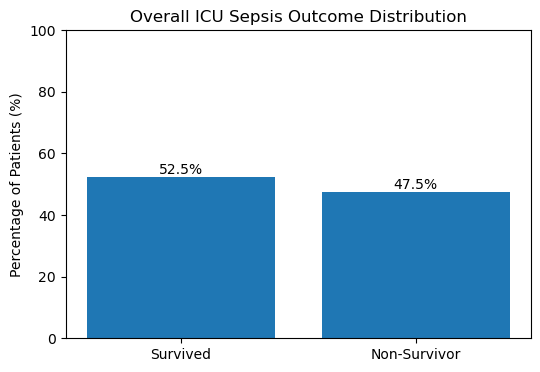

In [133]:
# Chart 1: Overall mortality rate.
# This chart provides a simple baseline view of mortality in the ICU sepsis cohort.
overall_mortality = df['mortality'].mean() * 100
survival_rate = 100 - overall_mortality

plt.figure(figsize=(6, 4))
plt.bar(['Survived', 'Non-Survivor'], [survival_rate, overall_mortality])
plt.title('Overall ICU Sepsis Outcome Distribution')
plt.ylabel('Percentage of Patients (%)')
plt.ylim(0, 100)

# Add percentage labels above each bar.
for index, value in enumerate([survival_rate, overall_mortality]):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center')

plt.show()


**Figure 1. Overall mortality rate:** The cohort demonstrated a substantial mortality burden, with nearly half of ICU sepsis patients classified as non-survivors in this dataset. This establishes the baseline outcome rate for the rest of the analysis.


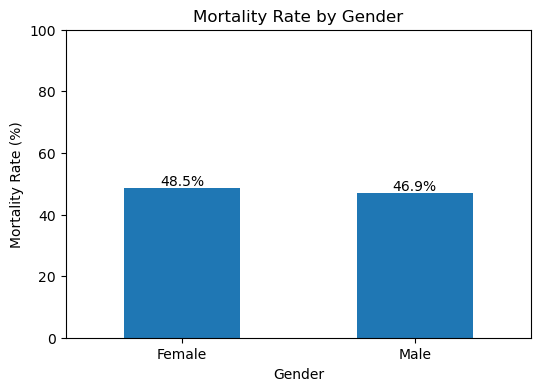

In [134]:
# Chart 2: Mortality rate by gender.
# Mortality is calculated as the mean of the binary mortality variable within each gender group.
gender_mortality = df.groupby('gender_label')['mortality'].mean().reindex(['Female', 'Male']) * 100

plt.figure(figsize=(6, 4))
gender_mortality.plot(kind='bar')
plt.title('Mortality Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Mortality Rate (%)')
plt.ylim(0, 100)
plt.xticks(rotation=0)

# Add percentage labels above each bar.
for index, value in enumerate(gender_mortality):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center')

plt.show()


**Figure 2. Mortality by gender:** Mortality rates differed slightly between female and male patients. The difference was modest, but gender may still be useful as a demographic variable in future predictive modeling.


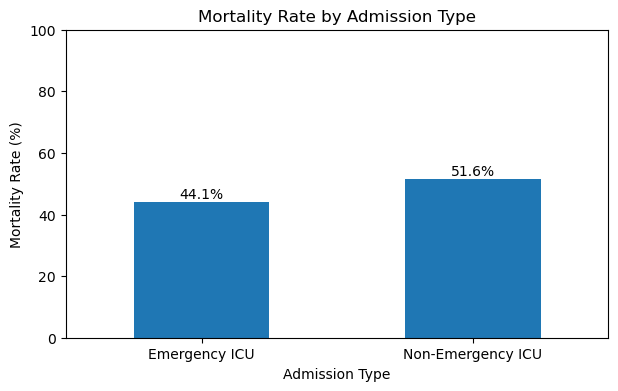

In [135]:
# Chart 3: Mortality rate by admission type / patient accommodation.
# This compares mortality patterns across emergency and non-emergency ICU pathways.
admission_mortality = (
    df.groupby('admission_type_label')['mortality']
    .mean()
    .reindex(['Emergency ICU', 'Non-Emergency ICU']) * 100
)

plt.figure(figsize=(7, 4))
admission_mortality.plot(kind='bar')
plt.title('Mortality Rate by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Mortality Rate (%)')
plt.ylim(0, 100)
plt.xticks(rotation=0)

# Add percentage labels above each bar.
for index, value in enumerate(admission_mortality):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center')

plt.show()


**Figure 3. Mortality by admission type:** Mortality was higher among non-emergency ICU patients compared with emergency ICU patients. This may reflect differences in patient complexity, admission pathway, illness trajectory, or underlying comorbidity burden.


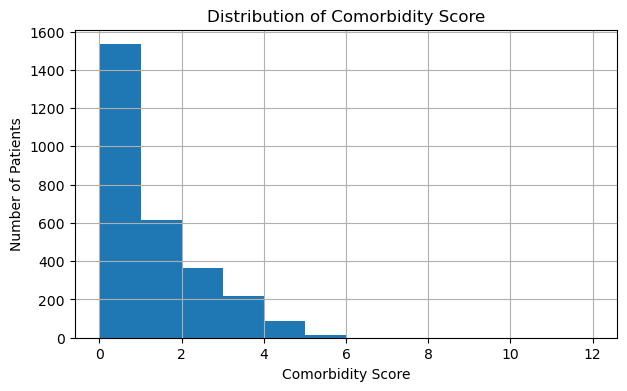

In [136]:
# Chart 4: Distribution of comorbidity score.
# The comorbidity score represents the number of documented chronic conditions for each patient.
plt.figure(figsize=(7, 4))
df['comorbidity_score'].hist(bins=range(int(df['comorbidity_score'].min()), int(df['comorbidity_score'].max()) + 2))
plt.title('Distribution of Comorbidity Score')
plt.xlabel('Comorbidity Score')
plt.ylabel('Number of Patients')
plt.show()


**Figure 4. Comorbidity score distribution:** The comorbidity score varied across the cohort, indicating differences in underlying chronic disease burden. This supports including comorbidity-related variables in future mortality risk modeling.


## Visualization Summary

The exploratory visualizations suggest that mortality among ICU patients with sepsis may be influenced by multiple patient and clinical factors. The overall mortality rate was high, reflecting the severity of illness in this cohort. Mortality differed slightly by gender and more noticeably by admission type, while the distribution of comorbidity scores demonstrated variation in chronic disease burden across patients. Collectively, these findings show how exploratory data analysis can identify clinically meaningful patterns and guide future predictive modeling or risk stratification work.


## Key Findings

### 1. Overall Mortality
The overall ICU sepsis mortality rate in this dataset was **47.5%**, demonstrating a substantial outcome burden among critically ill patients with sepsis.

### 2. Demographic Differences
Mortality differed slightly by gender:

- Female patients: **48.5%** mortality
- Male patients: **46.9%** mortality

The difference was relatively small, but gender may still be worth retaining as a demographic variable in future modeling.

### 3. Comorbidity Burden
A simple additive comorbidity score was created to estimate documented chronic disease burden. In this dataset, the relationship between comorbidity score and mortality was **not strictly linear**. This suggests that comorbidity burden may be useful for analysis, but it should be interpreted cautiously and evaluated further in predictive modeling.

### 4. Admission Pathway / Patient Accommodation
Mortality differed more noticeably by admission pathway. Non-emergency ICU patients demonstrated higher mortality than emergency ICU patients, suggesting that admission context and patient pathway may be important factors in outcome analysis.

### 5. Variables for Future Modeling
Variables that may warrant further evaluation in predictive modeling include age, gender, admission type, length of ICU stay, oxygen saturation, blood pressure, NT-proBNP, missingness indicators, and comorbidity score.


## Variables for Future Predictive Modeling

Based on the exploratory analysis and clinical relevance, the following variables may warrant further investigation in a mortality prediction model:

- **Age**: Non-survivors were older on average than survivors.
- **Admission pathway / patient accommodation**: Non-emergency ICU patients had higher mortality than emergency ICU patients.
- **Gender**: Mortality differed slightly between male and female patients.
- **Comorbidity score**: The relationship with mortality was not linear, but it may still contribute to risk prediction.
- **NT-proBNP**: This biomarker may reflect cardiac strain or severity of illness and may be useful in future modeling.
- **Oxygen saturation and vital signs**: These variables may reflect physiologic instability and could improve prediction when combined with other features.


## Executive Summary

This project demonstrates an end-to-end healthcare analytics workflow using ICU sepsis patient data. The analysis included data cleaning, missing data assessment, feature engineering, exploratory analysis, visualization, and interpretation of mortality-related trends.

Key results included an overall mortality rate of **47.5%**. Mortality was slightly higher among female patients than male patients in this dataset. The clearest observed difference was by admission pathway, with non-emergency ICU patients demonstrating higher mortality than emergency ICU patients. A simple comorbidity score was developed to summarize chronic disease burden, although its relationship with mortality was not strictly linear.

From a Clinical Informatics and Healthcare Analytics perspective, this project demonstrates how clinical expertise and data analysis can be combined to identify patterns, generate hypotheses, and support future predictive modeling efforts. The findings are exploratory and intended for educational and portfolio purposes rather than direct clinical decision-making.


## Future Work

Future analyses could build on this project by adding:

- Logistic regression for mortality prediction
- Feature importance analysis to identify the strongest predictors of mortality
- Train/test split validation to reduce overfitting
- Additional visualization of mortality trends by age, admission pathway, and physiologic variables


## About the Author

**Vanessa Lowry, RN, PhD**

Registered Nurse with 17+ years of experience in critical care, perioperative services, and healthcare leadership. PhD-trained physicist with interests in Healthcare Analytics, Clinical Informatics, Process Improvement, and Data-Driven Decision Making.

**Technical Skills Demonstrated:** Python, Pandas, NumPy, Matplotlib, data cleaning, exploratory data analysis, feature engineering, healthcare analytics, and clinical interpretation.

**GitHub:** https://github.com/vanessadata77  
**LinkedIn:** www.linkedin.com/in/vanessa-lowry
